# Fine-Tuning Embeddings for Feature Extraction & RAG
### 90-minute hands-on lab

**Before anything else:** `Runtime → Change runtime type → T4 GPU` — then run the install cell below so it works in the background while we lecture.

**What we'll do:**
- **Part A — Embeddings 101:** encode text, measure similarity, visualize the space.
- **Part B — Baseline retrieval:** build a proper evaluation set and discover that a plain pretrained LM is a *terrible* embedding model.
- **Part C — Fine-tune:** contrastive training with in-batch negatives (`MultipleNegativesRankingLoss`), ~3–5 min on a T4.
- **Part D — Re-evaluate:** watch Recall@k and MRR jump.
- **Part E — Use it:** frozen embeddings as classifier features + a mini RAG pipeline with FAISS.
- **Part F — Bonus:** hard negatives, Matryoshka, synthetic training data.


In [ ]:
%pip install -q -U sentence-transformers datasets accelerate faiss-cpu scikit-learn matplotlib


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cpu":
    print("WARNING: no GPU found. Runtime -> Change runtime type -> T4 GPU.")
    print("(CPU works too, just slower — shrink the dataset sizes in Part B.)")


Device: cpu
(CPU works too, just slower — shrink the dataset sizes in Part B.)


---
## Part A — Embeddings 101

An **embedding model** maps text → a fixed-size vector such that *geometry encodes meaning*:
texts that mean similar things end up close together (high cosine similarity).

We start with `all-MiniLM-L6-v2`: 22M params, 384 dims, a classic general-purpose sentence embedder.


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

sentences = [
    "The cattle are grazing in the north pasture.",
    "Cows feed on grass in the field.",
    "The stock market fell sharply today.",
    "Equity prices dropped steeply this afternoon.",
    "How do I reset my router?",
    "My wifi keeps disconnecting.",
    "Photosynthesis converts sunlight into chemical energy.",
]

emb = model.encode(sentences, normalize_embeddings=True)
print("Shape:", emb.shape)  # (7 sentences, 384 dims)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Shape: (7, 384)


With **normalized** vectors, cosine similarity is just a dot product.
Watch the block structure: paraphrases score high, unrelated topics score low —
*nothing here matched keywords* ("cattle" vs "cows", "fell" vs "dropped").


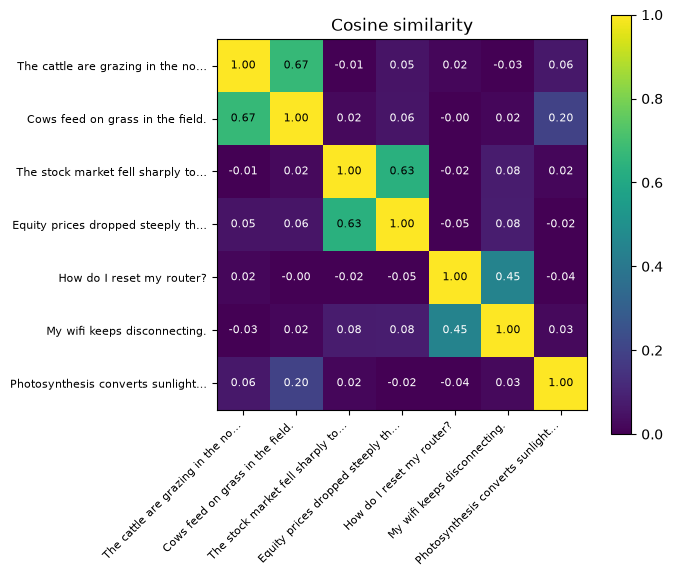

In [ ]:
sim = emb @ emb.T  # cosine similarity matrix (vectors are normalized)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim, vmin=0, vmax=1, cmap="viridis")
short = [s[:32] + ("…" if len(s) > 32 else "") for s in sentences]
ax.set_xticks(range(len(sentences)), short, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(sentences)), short, fontsize=8)
for i in range(len(sentences)):
    for j in range(len(sentences)):
        ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center",
                color="white" if sim[i, j] < 0.6 else "black", fontsize=8)
fig.colorbar(im)
ax.set_title("Cosine similarity")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import plotly.express as px

# Reduce embeddings to three principal components
xyz = PCA(n_components=3).fit_transform(emb)

# Create a dataframe for Plotly
plot_df = pd.DataFrame({
    "PC1": xyz[:, 0],
    "PC2": xyz[:, 1],
    "PC3": xyz[:, 2],
    "Sentence": short
})

# Interactive 3D scatter plot
fig = px.scatter_3d(
    plot_df,
    x="PC1",
    y="PC2",
    z="PC3",
    text="Sentence",
    hover_name="Sentence",
    title="Sentences in Embedding Space (PCA to 3D)"
)

fig.update_traces(
    marker=dict(size=6, opacity=0.8),
    textposition="top center"
)

fig.update_layout(
    width=900,
    height=700,
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    )
)

fig.show()

##**Practical Example**

In [ ]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device=device
)

# ============================================================
# 20 COW-NUTRITION SENTENCES
# ============================================================

nutrition_sentences = [
    "Dairy cows consume balanced rations to support milk production and body maintenance.",
    "Early-lactation dairy cows require high energy intake to meet the demands of milk synthesis.",
    "High-quality forage improves dry matter intake and nutrient supply in dairy cows.",
    "Dairy cows require adequate crude protein for milk protein synthesis.",
    "Neutral detergent fiber is essential for rumination and healthy rumen function in dairy cows.",
    "Fresh drinking water supports feed intake, digestion, and milk production in dairy cows.",
    "Corn silage provides fermentable energy and effective fiber to lactating dairy cows.",
    "Alfalfa hay supplies protein, fiber, calcium, and other nutrients to dairy cows.",
    "Mineral supplementation helps meet the nutrient requirements of high-producing dairy cows.",
    "Vitamins support immunity, metabolism, reproduction, and udder health in dairy cows.",
    "Rumen microorganisms ferment feed and produce nutrients used by dairy cows for milk production.",
    "Dairy cows ruminate to increase saliva production and maintain a stable rumen pH.",
    "Dry matter intake generally increases as dairy cows approach peak milk production.",
    "Heat stress reduces feed intake and nutrient availability in dairy cows.",
    "Gradual dietary changes help dairy cows adapt to high-energy lactation diets.",
    "Excessive grain intake can cause subacute ruminal acidosis in dairy cows.",
    "Dietary starch provides fermentable energy for rumen microbes and milk production in dairy cows.",
    "Forage digestibility strongly influences energy intake and performance in dairy cows.",
    "Highly digestible forage can improve feed efficiency and milk yield in dairy cows.",
    "Excessive forage lignification reduces fiber digestion and nutrient availability in dairy cows.",
]

# ============================================================
# 20 COW-REPRODUCTION SENTENCES
# ============================================================

reproduction_sentences = [
    "Dairy cows require regular estrous cycles to maintain reproductive efficiency.",
    "Dairy cows display increased activity and mounting behavior during estrus.",
    "Accurate estrus detection improves artificial insemination timing in dairy cows.",
    "Dairy cows should be inseminated at the appropriate time relative to ovulation.",
    "Artificial insemination allows dairy cows to be bred using genetically selected semen.",
    "Dairy cows require normal ovarian function to establish pregnancy.",
    "Progesterone supports pregnancy maintenance in dairy cows.",
    "The corpus luteum produces progesterone after ovulation in dairy cows.",
    "Reproductive synchronization helps coordinate ovulation among dairy cows.",
    "Timed artificial insemination reduces dependence on visual estrus detection in dairy cows.",
    "Pregnancy diagnosis helps identify open dairy cows soon after breeding.",
    "Ultrasonography can be used to evaluate reproductive structures in dairy cows.",
    "Dairy cows need adequate body condition to support conception and pregnancy.",
    "Negative energy balance can delay ovarian activity in postpartum dairy cows.",
    "Excessive body condition loss can reduce fertility in dairy cows.",
    "Heat stress can reduce estrus expression and conception rates in dairy cows.",
    "Postpartum uterine diseases can impair reproductive performance in dairy cows.",
    "Dairy cows require sufficient recovery time after calving before breeding.",
    "Shorter days open can improve reproductive and economic efficiency in dairy cows.",
    "Effective reproductive management supports pregnancy rates and herd productivity in dairy cows.",
]

# ============================================================
# 20 ECONOMIC SENTENCES
# ============================================================

economics_sentences = [
    "The stock market increased after the release of positive economic data.",
    "Inflation reduces the purchasing power of consumers over time.",
    "Interest rates influence borrowing, saving, and investment decisions.",
    "Economic growth is commonly measured using gross domestic product.",
    "Higher consumer demand can increase the prices of goods and services.",
    "Unemployment rises when businesses reduce production and hiring.",
    "Central banks adjust monetary policy to maintain price stability.",
    "Government spending can stimulate economic activity during a recession.",
    "Taxes provide revenue for public services and infrastructure.",
    "International trade allows countries to exchange goods and services.",
    "Supply chain disruptions can increase production costs and consumer prices.",
    "A budget deficit occurs when government spending exceeds government revenue.",
    "Currency exchange rates affect the cost of imports and exports.",
    "Competition encourages companies to improve efficiency and reduce prices.",
    "Consumer confidence can influence household spending decisions.",
    "Labor productivity measures the output produced by each worker.",
    "A recession is characterized by a significant decline in economic activity.",
    "Investors diversify their portfolios to reduce financial risk.",
    "The law of supply and demand helps explain changes in market prices.",
    "Economic inequality describes differences in income and wealth among people.",
]

# Combine the two groups
sentences = nutrition_sentences + reproduction_sentences + economics_sentences

# Labels for PCA visualization or classification
labels = (
    ["Nutrition"] * len(nutrition_sentences)
    + ["Reproduction"] * len(reproduction_sentences)
    + ["Economics"] * len(economics_sentences)
)

# Create embeddings
emb = model.encode(
    sentences,
    normalize_embeddings=True,
    show_progress_bar=True
)

print("Nutrition:", len(nutrition_sentences))
print("Reproduction:", len(reproduction_sentences))
print("Economics:", len(economics_sentences))
print("Total:", len(sentences))
print("Embedding shape:", emb.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Nutrition: 20
Reproduction: 20
Economics: 20
Total: 60
Embedding shape: (60, 384)


In [ ]:
#Estrus expression can be impacted by poor nutrition management.
#Market fluctuations can affect livestock prices.
#Poor reproductive performance increases farm expenses.
#Dry matter intake can affect estrus expression.
new_sentence = (
    "Market fluctuations can affect prices."
)

print("\nNew sentence:")
print(new_sentence)


New sentence:
Market fluctuations can affect prices.


In [ ]:
new_emb = model.encode(
    [new_sentence],
    normalize_embeddings=True,
    convert_to_numpy=True
)[0]

print("\nNew embedding shape:", new_emb.shape)



New embedding shape: (384,)


In [ ]:
cosine_similarities = emb @ new_emb

similarity_df = pd.DataFrame({
    "Sentence": sentences,
    "Category": labels,
    "Cosine similarity": cosine_similarities
})

similarity_df = similarity_df.sort_values(
    by="Cosine similarity",
    ascending=False
).reset_index(drop=True)

top_n = 10

print(f"\nTop {top_n} most similar sentences")
print("--------------------------------")

print(
    similarity_df[
        ["Category", "Cosine similarity", "Sentence"]
    ]
    .head(top_n)
    .round({"Cosine similarity": 4})
    .to_string(index=False)
)


Top 10 most similar sentences
--------------------------------
 Category  Cosine similarity                                                                    Sentence
Economics             0.6354        The law of supply and demand helps explain changes in market prices.
Economics             0.5582 Supply chain disruptions can increase production costs and consumer prices.
Economics             0.5027       Higher consumer demand can increase the prices of goods and services.
Economics             0.5000     The stock market increased after the release of positive economic data.
Economics             0.4591              Inflation reduces the purchasing power of consumers over time.
Economics             0.4497             Currency exchange rates affect the cost of imports and exports.
Economics             0.4480   Competition encourages companies to improve efficiency and reduce prices.
Economics             0.4458           Central banks adjust monetary policy to maintain price st

In [ ]:
category_scores = (
    similarity_df
    .groupby("Category", as_index=False)
    .agg(
        Mean_similarity=("Cosine similarity", "mean"),
        Maximum_similarity=("Cosine similarity", "max"),
        Minimum_similarity=("Cosine similarity", "min"),
        Similarity_SD=("Cosine similarity", "std")
    )
    .sort_values(
        by="Mean_similarity",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nCosine similarity by category")
print("-----------------------------")

print(
    category_scores.round(4).to_string(index=False)
)


Cosine similarity by category
-----------------------------
    Category  Mean_similarity  Maximum_similarity  Minimum_similarity  Similarity_SD
   Economics           0.3526              0.6354              0.0753         0.1466
Reproduction           0.0337              0.1539             -0.0503         0.0546
   Nutrition           0.0328              0.1996             -0.0703         0.0634


In [ ]:
# Embed the new sentence
new_emb = model.encode(
    [new_sentence],
    normalize_embeddings=True,
    convert_to_numpy=True
)[0]

# Classify using mean cosine similarity by topic
similarities = emb @ new_emb

category_scores = (
    pd.DataFrame({
        "Category": labels,
        "Similarity": similarities
    })
    .groupby("Category")["Similarity"]
    .mean()
)

predicted_category = category_scores.idxmax()

print("Category scores:")
print(category_scores.round(4))
print("\nPredicted category:", predicted_category)

# Combine training and new sentence embeddings
all_emb = np.vstack([
    emb,
    new_emb.reshape(1, -1)
])

# Reduce embeddings to three dimensions
xyz = PCA(n_components=3).fit_transform(all_emb)

# Create dataframe
plot_df = pd.DataFrame({
    "PC1": xyz[:, 0],
    "PC2": xyz[:, 1],
    "PC3": xyz[:, 2],
    "Sentence": sentences + [new_sentence],
    "Category": list(labels) + [predicted_category],
    "Point type": (
        ["Training sentence"] * len(sentences)
        + ["New sentence"]
    )
})

# Interactive 3D plot
fig = px.scatter_3d(
    plot_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Category",
    symbol="Point type",
    hover_name="Sentence",
    color_discrete_map={
        "Nutrition": "green",
        "Reproduction": "purple",
        "Economics": "orange"
    },
    symbol_map={
        "Training sentence": "circle",
        "New sentence": "diamond"
    },
    title=f"New Sentence Classified as {predicted_category}"
)

fig.update_traces(
    marker=dict(size=7, opacity=0.8)
)

fig.show()

Category scores:
Category
Economics       0.3526
Nutrition       0.0328
Reproduction    0.0337
Name: Similarity, dtype: float32

Predicted category: Economics


---
## Part B — Baseline retrieval: measure before you train

**Dataset:** [Natural Questions](https://huggingface.co/datasets/sentence-transformers/natural-questions) —
real Google queries paired with the Wikipedia passage that answers them. Exactly the *asymmetric*
(short query → long document) shape that RAG retrieval needs.

We build:
- **10,000 training pairs** (question, answer-passage) — used only in Part C.
- **1,000 held-out eval queries**, searching a corpus of **10,000 passages** (their 1,000 true answers + 9,000 distractors).

**Metrics:**
- **Recall@k** — is the true passage in the top k results?
- **MRR@10** — 1/rank of the first relevant result (position matters).


In [ ]:
from datasets import load_dataset

nq = load_dataset("sentence-transformers/natural-questions", split="train")
nq = nq.shuffle(seed=42).select(range(20000))
print(nq)
print("\nExample:")
print("  Q:", nq[0]["query"][:100])
print("  A:", nq[0]["answer"][:200], "…")


Dataset({
    features: ['query', 'answer'],
    num_rows: 20000
})

Example:
  Q: who are the basques and where do they live
  A: Basques The Basques (/bɑːsks/ or /bæsks/; Basque: euskaldunak [eus̺kaldunak]; Spanish: vascos [ˈbaskos]; French: basques [bask]) are an indigenous ethnic group[5][6][7] characterised by the Basque lan …


In [ ]:
# --- build train / eval splits ------------------------------------------
N_TRAIN, N_EVAL, N_DISTRACT = 2_000, 200, 1_800  # shrink these if on CPU

train_ds = nq.select(range(N_TRAIN))
eval_ds  = nq.select(range(N_TRAIN, N_TRAIN + N_EVAL))
distract = nq.select(range(N_TRAIN + N_EVAL, N_TRAIN + N_EVAL + N_DISTRACT))

# Corpus = 1,000 true answers + 9,000 distractor passages
queries       = {f"q{i}": q for i, q in enumerate(eval_ds["query"])}
corpus        = {f"d{i}": a for i, a in enumerate(eval_ds["answer"])}
corpus       |= {f"x{i}": a for i, a in enumerate(distract["answer"])}
relevant_docs = {f"q{i}": {f"d{i}"} for i in range(len(eval_ds))}

print(f"{len(queries)} eval queries, {len(corpus)} corpus passages")


200 eval queries, 2000 corpus passages


In [ ]:
from sentence_transformers.sentence_transformer.evaluation import InformationRetrievalEvaluator

ir_eval = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    accuracy_at_k=[1, 5, 10],
    mrr_at_k=[10],
    ndcg_at_k=[10],
    map_at_k=[10],
    name="nq-eval",
    show_progress_bar=True,
    batch_size=256,
)

results = {}  # model name -> metrics dict

def evaluate(model, label):
    metrics = ir_eval(model)
    results[label] = metrics
    print(f"\n=== {label} ===")
    for k in [1, 5, 10]:
        print(f"  Recall@{k}: {metrics[f'nq-eval_cosine_accuracy@{k}']:.3f}")
    print(f"  MRR@10:    {metrics['nq-eval_cosine_mrr@10']:.3f}")
    return metrics


### Baseline 1 — raw DistilBERT (a pretrained LM, *not* an embedding model)

`SentenceTransformer("distilbert-base-uncased")` wraps the plain LM with mean pooling.
DistilBERT has seen billions of words… but it was trained to *predict masked tokens*,
not to make cosine similarity meaningful. **Prediction: it will be bad.** Let's check.

(Encoding 11k texts takes ~1 min on a T4.)


In [ ]:
distilbert = SentenceTransformer("distilbert-base-uncased", device=device)
evaluate(distilbert, "DistilBERT (raw)")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [08:58<00:00, 538.19s/it]


=== DistilBERT (raw) ===
  Recall@1: 0.375
  Recall@5: 0.660
  Recall@10: 0.710
  MRR@10:    0.486


{'nq-eval_cosine_accuracy@1': 0.375,
 'nq-eval_cosine_accuracy@5': 0.66,
 'nq-eval_cosine_accuracy@10': 0.71,
 'nq-eval_cosine_precision@1': 0.375,
 'nq-eval_cosine_precision@3': 0.18833333333333332,
 'nq-eval_cosine_precision@5': 0.132,
 'nq-eval_cosine_precision@10': 0.071,
 'nq-eval_cosine_recall@1': 0.375,
 'nq-eval_cosine_recall@3': 0.565,
 'nq-eval_cosine_recall@5': 0.66,
 'nq-eval_cosine_recall@10': 0.71,
 'nq-eval_cosine_ndcg@10': 0.540786520059069,
 'nq-eval_cosine_mrr@10': 0.4864960317460318,
 'nq-eval_cosine_map@10': 0.4864960317460318}

### Baseline 2 — all-MiniLM-L6-v2 (purpose-built embedder)

Same transformer architecture family, **5× fewer parameters** — but trained contrastively on 1B+ text pairs.


In [ ]:
evaluate(model, "all-MiniLM-L6-v2")


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [02:17<00:00, 137.07s/it]


=== all-MiniLM-L6-v2 ===
  Recall@1: 0.920
  Recall@5: 0.990
  Recall@10: 1.000
  MRR@10:    0.952


{'nq-eval_cosine_accuracy@1': 0.92,
 'nq-eval_cosine_accuracy@5': 0.99,
 'nq-eval_cosine_accuracy@10': 1.0,
 'nq-eval_cosine_precision@1': 0.92,
 'nq-eval_cosine_precision@3': 0.33,
 'nq-eval_cosine_precision@5': 0.198,
 'nq-eval_cosine_precision@10': 0.1,
 'nq-eval_cosine_recall@1': 0.92,
 'nq-eval_cosine_recall@3': 0.99,
 'nq-eval_cosine_recall@5': 0.99,
 'nq-eval_cosine_recall@10': 1.0,
 'nq-eval_cosine_ndcg@10': 0.9641181989778451,
 'nq-eval_cosine_mrr@10': 0.9521666666666668,
 'nq-eval_cosine_map@10': 0.9521666666666667}

> **The point:** the gap you just measured is not about model size or pretraining data —
> it's entirely about the *training objective*. In Part C we close that gap in ~150 gradient steps.


---
## Part C — Fine-tune with contrastive learning

**`MultipleNegativesRankingLoss` (MNRL / InfoNCE):** feed batches of (question, answer) pairs.
For each question, its own answer is the **positive**; *every other answer in the batch* is a **negative** — for free.

With batch size 64, each question must pick its answer out of a 64-way lineup.
Cross-entropy over the similarity matrix pulls positives together and pushes the other 63 apart.

> Bigger batch → more negatives → harder task → better model. This is why embedding papers obsess over batch size.


In [ ]:
from sentence_transformers import SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers.training_args import BatchSamplers

# Fresh copy of the raw LM — this is the model we'll transform
ft_model = SentenceTransformer("distilbert-base-uncased", device=device)

# MNRL expects (anchor, positive) columns, in that order
train_pairs = train_ds.select_columns(["query", "answer"])
loss = MultipleNegativesRankingLoss(ft_model)

args = SentenceTransformerTrainingArguments(
    output_dir="./nq-distilbert-ft",
    num_train_epochs=1,
    per_device_train_batch_size=8,     # = 63 in-batch negatives per anchor
    learning_rate=2e-5,
    warmup_ratio=0.1,
    fp16=(device == "cuda"),
    batch_sampler=BatchSamplers.NO_DUPLICATES,  # duplicate answers in a batch = false negatives
    logging_steps=10,
    report_to="none",
)

trainer = SentenceTransformerTrainer(
    model=ft_model,
    args=args,
    train_dataset=train_pairs,
    loss=loss,
)
trainer.train()   # ~3-5 min on a T4 (157 steps)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
10,0.493388
20,0.285970
30,0.125316
40,0.083280
50,0.125597
60,0.127777
70,0.014480
80,0.132729
90,0.132221
100,0.045358


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=0.08733742237091065, metrics={'train_runtime': 2279.2099, 'train_samples_per_second': 0.877, 'train_steps_per_second': 0.11, 'total_flos': 0.0, 'train_loss': 0.08733742237091065, 'epoch': 1.0})

**While it trains, discuss:**
- 10,000 pairs × 1 epoch ÷ 64 = **157 steps**. That's all it takes.
- Watch the loss: it should drop fast in the first ~40 steps (from ~4.16 = ln 64, i.e. random guessing over the batch).
- `NO_DUPLICATES`: if the same answer appears twice in a batch, one copy becomes a *false negative*. The sampler prevents that.


---
## Part D — Re-evaluate: did it work?


In [ ]:
evaluate(ft_model, "DistilBERT (fine-tuned)")


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [08:24<00:00, 504.78s/it]


=== DistilBERT (fine-tuned) ===
  Recall@1: 0.790
  Recall@5: 0.910
  Recall@10: 0.940
  MRR@10:    0.842


{'nq-eval_cosine_accuracy@1': 0.79,
 'nq-eval_cosine_accuracy@5': 0.91,
 'nq-eval_cosine_accuracy@10': 0.94,
 'nq-eval_cosine_precision@1': 0.79,
 'nq-eval_cosine_precision@3': 0.29333333333333333,
 'nq-eval_cosine_precision@5': 0.182,
 'nq-eval_cosine_precision@10': 0.09399999999999999,
 'nq-eval_cosine_recall@1': 0.79,
 'nq-eval_cosine_recall@3': 0.88,
 'nq-eval_cosine_recall@5': 0.91,
 'nq-eval_cosine_recall@10': 0.94,
 'nq-eval_cosine_ndcg@10': 0.8660847420514937,
 'nq-eval_cosine_mrr@10': 0.8422281746031747,
 'nq-eval_cosine_map@10': 0.8422281746031746}

In [ ]:
# Side-by-side comparison
labels = list(results.keys())
metrics_to_plot = [("cosine_accuracy@1", "Recall@1"),
                   ("cosine_accuracy@10", "Recall@10"),
                   ("cosine_mrr@10", "MRR@10")]

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(metrics_to_plot))
width = 0.8 / len(labels)
for i, label in enumerate(labels):
    vals = [results[label][f"nq-eval_{key}"] for key, _ in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=label)
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
ax.set_xticks(x + width, [name for _, name in metrics_to_plot])
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("Retrieval quality: before vs. after fine-tuning")
plt.tight_layout()
plt.show()


**What just happened:** ~150 gradient steps turned a model that was near-useless for retrieval
into one competitive with a purpose-built embedder — *on this task's notion of similarity*.

The same recipe applies unchanged to **your** domain: veterinary notes, legal clauses, internal wikis.
All you need is (query, relevant-passage) pairs. (No pairs? See Part F: synthetic data.)


---
## Part E1 — Embeddings as features (feature extraction)

The second big use of embedding models: **freeze the encoder, use the vector as input features**
for a lightweight downstream model (logistic regression, XGBoost, k-means, anomaly detection…).

Classifying AG News headlines (4 classes) with 2,000 labeled examples:


In [ ]:
from sklearn.linear_model import LogisticRegression

ag = load_dataset("fancyzhx/ag_news")
ag_train = ag["train"].shuffle(seed=42).select(range(2000))
ag_test  = ag["test"].shuffle(seed=42).select(range(1000))

for label, m in [("DistilBERT (raw)", distilbert),
                 ("all-MiniLM-L6-v2", model),
                 ("DistilBERT (our fine-tune)", ft_model)]:
    Xtr = m.encode(ag_train["text"], normalize_embeddings=True, batch_size=256)
    Xte = m.encode(ag_test["text"],  normalize_embeddings=True, batch_size=256)
    clf = LogisticRegression(max_iter=2000).fit(Xtr, ag_train["label"])
    print(f"{label:32s} accuracy: {clf.score(Xte, ag_test['label']):.3f}")


**Discussion:** all three make decent features — classification is a much easier geometric ask
than retrieval (a linear probe can carve up even a "messy" space). Retrieval tuning may help, hurt, or
do nothing here, because we optimized for *question→answer* similarity, not topic separation.
**Lesson: fine-tune for the similarity your task actually needs** (for classification specifically,
look up SetFit — contrastive fine-tuning from just 8–64 labels per class).


## Part E2 — Mini RAG pipeline

Retrieval-Augmented Generation = **your fine-tuned retriever + any LLM**:

1. Embed the corpus once → store in a vector index (FAISS here; pgvector/Qdrant/etc. in production).
2. Embed the query with the **same model**, retrieve top-k.
3. Paste the retrieved passages into the LLM prompt as grounding context.


In [ ]:
import faiss

# 1) Index the corpus (in production: do once, store, re-do when the model changes!)
doc_ids   = list(corpus.keys())
doc_texts = [corpus[d] for d in doc_ids]
doc_emb   = ft_model.encode(doc_texts, normalize_embeddings=True,
                            batch_size=256, show_progress_bar=True)

index = faiss.IndexFlatIP(doc_emb.shape[1])   # inner product == cosine (normalized)
index.add(doc_emb)
print(index.ntotal, "passages indexed")


In [ ]:
def retrieve(question, k=3):
    q = ft_model.encode([question], normalize_embeddings=True)
    scores, idx = index.search(q, k)
    return [(doc_ids[i], scores[0][j], doc_texts[i]) for j, i in enumerate(idx[0])]

def build_rag_prompt(question, k=3):
    hits = retrieve(question, k)
    context = "\n\n".join(f"[{j+1}] {text[:500]}" for j, (_, _, text) in enumerate(hits))
    return hits, (
        "Answer the question using ONLY the context below. "
        "If the context is insufficient, say so.\n\n"
        f"Context:\n{context}\n\nQuestion: {question}\nAnswer:"
    )

question = eval_ds[7]["query"]   # try your own question too!
hits, prompt = build_rag_prompt(question)

print("QUESTION:", question, "\n")
for doc_id, score, text in hits:
    print(f"  {score:.3f}  [{doc_id}]  {text[:110]}…")
print("\n--- PROMPT SENT TO THE LLM " + "-" * 40)
print(prompt[:1200])


In [ ]:
# Optional: actually generate the answer (needs an API key)
# %pip install -q anthropic
# from anthropic import Anthropic
# client = Anthropic(api_key="sk-ant-...")
# msg = client.messages.create(model="claude-sonnet-5", max_tokens=300,
#                              messages=[{"role": "user", "content": prompt}])
# print(msg.content[0].text)


In [ ]:
def ask_rag(question, k=3):
    hits, prompt = build_rag_prompt(question, k=k)

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    inputs = llm.tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )

    inputs = {
        key: value.to(llm.model.device)
        for key, value in inputs.items()
    }

    outputs = llm.model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False,
        pad_token_id=llm.tokenizer.eos_token_id
    )

    new_tokens = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    answer = llm.tokenizer.decode(
        new_tokens,
        skip_special_tokens=True
    )

    return hits, answer.strip()

In [ ]:
while True:
    question = input("\nAsk a question or type 'exit': ")

    if question.lower() == "exit":
        break

    hits, answer = ask_rag(question, k=3)

    print("\nAnswer:")
    print(answer)

---
## Part F — Bonus techniques (homework material)

### 1. Hard negatives — the single biggest quality lever
In-batch negatives are mostly *easy* (random passages). Models improve most when trained against
passages that *look* relevant but aren't:


In [ ]:
# Mine hard negatives with a first-pass model, then retrain on (anchor, positive, negative) triplets
# from sentence_transformers.util import mine_hard_negatives
# hard_ds = mine_hard_negatives(
#     dataset=train_pairs,           # (query, answer) pairs
#     model=ft_model,                # model that proposes the candidates
#     num_negatives=3,
#     range_min=10,                  # skip top-10: likely false negatives!
#     margin=0.1,                    # negative must score below positive by this margin
#     sampling_strategy="top",
# )
# # then: MultipleNegativesRankingLoss on (anchor, positive, negative) — negatives now explicit AND in-batch


### 2. No training data? Generate it (synthetic pairs)
The standard bootstrap for a custom domain — for each of your document chunks, ask an LLM:

> *"Write 3 realistic search queries a user might type whose answer is contained in this passage.
> Vary phrasing; do not copy sentences verbatim. Passage: {chunk}"*

That gives (synthetic query, chunk) positives → exactly the format Part C used. Filter out
near-duplicates, hold out 10% of chunks for the golden eval set, and you have a full pipeline.

### 3. Matryoshka embeddings — truncatable vectors
Train so that the *first N dims* of the vector are themselves a good embedding → store 768 dims,
search with 128 for 6× cheaper indexes:


In [ ]:
# from sentence_transformers.losses import MatryoshkaLoss
# base_loss = MultipleNegativesRankingLoss(ft_model)
# loss = MatryoshkaLoss(ft_model, base_loss, matryoshka_dims=[768, 384, 128, 64])
# # ...same trainer as Part C. At inference: emb = model.encode(text)[:128]  (then re-normalize)


### 4. Save / share your model


In [ ]:
ft_model.save_pretrained("nq-distilbert-ft/final")
# or push to the Hub:
# ft_model.push_to_hub("your-username/nq-distilbert-ft")


---
## Exercises
1. **Batch size ablation:** retrain Part C with `per_device_train_batch_size` of 8 vs 64. How much Recall@10 do the extra in-batch negatives buy?
2. **Better starting point:** replace `distilbert-base-uncased` with `BAAI/bge-small-en-v1.5` in Part C. Does fine-tuning a *good* embedder on in-domain pairs still help?
3. **Hard negatives:** un-comment the mining cell, retrain on triplets, re-evaluate.
4. **Bring your own domain:** take 50+ documents you care about, generate synthetic queries (Part F.2), fine-tune, and report Recall@5 before/after.

## Takeaways
1. Embedding quality **caps** RAG quality — garbage retrieval in, garbage answers out.
2. A pretrained LM is not an embedding model; the **contrastive objective** is what creates one.
3. In-batch negatives make training cheap; **hard negatives** make it good.
4. **Measure first** (Recall@k / MRR on a held-out golden set), then train, then measure again.
5. Same encoder must embed queries **and** corpus — new model ⇒ re-embed everything.
